# Setup

In [ ]:
pip install numpy==1.26.4

In [35]:
import numpy as np

In [ ]:
pip install pyale

In [3]:
# Cell 1: imports
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import sklearn, numpy, joblib
from pathlib import Path

In [ ]:
print(sklearn.__version__)
print(numpy.__version__)
print(joblib.__version__)

In [5]:
# Cell 2: file paths
BASE_DIR = Path(".")

DATA_PATH = BASE_DIR / "WA_Fn-UseC_-HR-Employee-Attrition.csv"
SVM_PATH = BASE_DIR / "rm_col_recommended_blackbox_svm.joblib"
LOGREG_PATH = BASE_DIR / "rm_col_best_overall_logreg.joblib"

In [7]:
# Cell 2: file paths
BASE_DIR = Path(".")

DATA_PATH = BASE_DIR / "/Users/ashlyncho/Desktop/DBA5102/Sem2/5102_Sem2_GP/5102_part2-master/WA_Fn-UseC_-HR-Employee-Attrition.csv"
SVM_PATH = BASE_DIR / "/Users/ashlyncho/Desktop/DBA5102/Sem2/5102_Sem2_GP/5102_part2-master/rm_col_recommended_blackbox_svm.joblib"
LOGREG_PATH = BASE_DIR / "/Users/ashlyncho/Desktop/DBA5102/Sem2/5102_Sem2_GP/5102_part2-master/rm_col_best_overall_logreg.joblib"

In [9]:
# Cell 3: load raw data
df_raw = pd.read_csv(DATA_PATH)

print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [11]:
# Cell 4: reproduce the reduced-column dataset logic
constant_columns = [col for col in df_raw.columns if df_raw[col].nunique() == 1]

cols_to_remove = [
    "EmployeeCount",
    "StandardHours",
    "EmployeeNumber",
    "Over18",
    "JobLevel",
    "YearsAtCompany",
    "WorkLifeBalance",
    "MonthlyIncome",
    "PerformanceRating",
    "JobInvolvement",
    "HourlyRate",
    "DailyRate",
]

df_rm = df_raw.drop(columns=constant_columns, errors="ignore").drop(columns=cols_to_remove, errors="ignore")

print("Constant columns removed:", constant_columns)
print("Configured columns removed:", cols_to_remove)
print("Reduced dataframe shape:", df_rm.shape)
df_rm.head()

Constant columns removed: ['EmployeeCount', 'Over18', 'StandardHours']
Configured columns removed: ['EmployeeCount', 'StandardHours', 'EmployeeNumber', 'Over18', 'JobLevel', 'YearsAtCompany', 'WorkLifeBalance', 'MonthlyIncome', 'PerformanceRating', 'JobInvolvement', 'HourlyRate', 'DailyRate']
Reduced dataframe shape: (1470, 23)


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobRole,...,NumCompaniesWorked,OverTime,PercentSalaryHike,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,Sales Executive,...,8,Yes,11,1,0,8,0,4,0,5
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,Research Scientist,...,1,No,23,4,1,10,3,7,1,7
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,4,Male,Laboratory Technician,...,6,Yes,15,2,0,7,3,0,0,0
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,Research Scientist,...,1,Yes,11,3,0,8,3,7,3,0
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,Male,Laboratory Technician,...,9,No,12,4,1,6,3,2,2,2


In [13]:
# Cell 5: create X and y exactly as in the reduced pipeline
X = df_rm.drop(columns=["Attrition"]).copy()
y = df_rm["Attrition"].map({"Yes": 1, "No": 0}).copy()

print("X shape:", X.shape)
print("y mean (attrition rate):", y.mean())
print("\nColumns in X:")
print(X.columns.tolist())

X shape: (1470, 22)
y mean (attrition rate): 0.16122448979591836

Columns in X:
['Age', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [15]:
# Cell 6: load saved reduced-column models

svm_pipe = joblib.load(SVM_PATH)
logreg_pipe = joblib.load(LOGREG_PATH)

print("SVM loaded successfully:", type(svm_pipe))
print("LogReg loaded successfully:", type(logreg_pipe))

SVM loaded successfully: <class 'sklearn.pipeline.Pipeline'>
LogReg loaded successfully: <class 'sklearn.pipeline.Pipeline'>


In [17]:
print("SVM type:", type(svm_pipe))
print("LogReg type:", type(logreg_pipe))

print("\nSVM steps:")
for name, step in svm_pipe.steps:
    print(name, type(step))

print("\nLogReg steps:")
for name, step in logreg_pipe.steps:
    print(name, type(step))

SVM type: <class 'sklearn.pipeline.Pipeline'>
LogReg type: <class 'sklearn.pipeline.Pipeline'>

SVM steps:
prep <class 'sklearn.compose._column_transformer.ColumnTransformer'>
model <class 'sklearn.svm._classes.SVC'>

LogReg steps:
prep <class 'sklearn.compose._column_transformer.ColumnTransformer'>
model <class 'sklearn.linear_model._logistic.LogisticRegression'>


In [19]:
# Cell 7: inspect pipeline structure
print("SVM pipeline steps:", list(svm_pipe.named_steps.keys()))
print("LogReg pipeline steps:", list(logreg_pipe.named_steps.keys()))

prep = svm_pipe.named_steps["prep"]
svm_model = svm_pipe.named_steps["model"]

print("\nPreprocessor type:", type(prep))
print("Model type:", type(svm_model))

print("\nTransformer names inside preprocessor:")
for name, transformer, cols in prep.transformers:
    print(f"\nName: {name}")
    print("Transformer type:", type(transformer))
    if transformer in ("drop", "passthrough"):
        print("Transformer special value:", transformer)
    else:
        print("Columns:", cols if isinstance(cols, str) else list(cols)[:10])
        if hasattr(cols, "__len__") and not isinstance(cols, str):
            print("Number of columns:", len(cols))


SVM pipeline steps: ['prep', 'model']
LogReg pipeline steps: ['prep', 'model']

Preprocessor type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Model type: <class 'sklearn.svm._classes.SVC'>

Transformer names inside preprocessor:

Name: num
Transformer type: <class 'sklearn.pipeline.Pipeline'>
Columns: ['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel']
Number of columns: 15

Name: cat
Transformer type: <class 'sklearn.pipeline.Pipeline'>
Columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Number of columns: 7


In [21]:
# Cell 8: extract the raw feature groups expected by the saved pipeline
numeric_features = prep.transformers[0][2]
categorical_features = prep.transformers[1][2]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Total expected raw features:", len(numeric_features) + len(categorical_features))

Numeric features: ['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical features: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Total expected raw features: 22


In [23]:
# Cell 9: align X to exactly the features expected by the saved reduced pipeline
expected_features = list(numeric_features) + list(categorical_features)

missing_features = [c for c in expected_features if c not in X.columns]
extra_features = [c for c in X.columns if c not in expected_features]

print("Missing features:", missing_features)
print("Extra features:", extra_features)

X_model = X[expected_features].copy()

print("X_model shape:", X_model.shape)
X_model.head()

Missing features: []
Extra features: []
X_model shape: (1470, 22)


,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobSatisfaction,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,RelationshipSatisfaction,StockOptionLevel,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
0,41,1,2,2,4,19479,8,11,1,0,...,4,0,5,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Yes
1,49,8,1,3,2,24907,1,23,4,1,...,7,1,7,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,No
2,37,2,2,4,3,2396,6,15,2,0,...,0,0,0,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Yes
3,33,3,4,4,3,23159,1,11,3,0,...,7,3,0,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Yes
4,27,2,1,1,2,16632,9,12,4,1,...,2,2,2,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,No


In [25]:
# Cell 10: quick sanity check that the saved models run
svm_pred_proba = svm_pipe.predict_proba(X_model)[:, 1]
logreg_pred_proba = logreg_pipe.predict_proba(X_model)[:, 1]

print("SVM probability vector shape:", svm_pred_proba.shape)
print("LogReg probability vector shape:", logreg_pred_proba.shape)

print("\nFirst 5 SVM probabilities:", svm_pred_proba[:5])
print("First 5 LogReg probabilities:", logreg_pred_proba[:5])

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
SVM probability vector shape: (1470,)
LogReg probability vector shape: (1470,)

First 5 SVM probabilities: [0.74346192 0.00417443 0.43839656 0.30257763 0.53141508]
First 5 LogReg probabilities: [0.89784611 0.04670393 0.80664772 0.57703496 0.76819829]


In [27]:
# Cell 11: objects you will use later for XAI
prep = svm_pipe.named_steps["prep"]
svm_model = svm_pipe.named_steps["model"]

X_processed = prep.transform(X_model)

print("Processed matrix shape:", X_processed.shape)

# Optional: transformed feature names for later use
feature_names_after_prep = prep.get_feature_names_out()
print("Number of transformed feature names:", len(feature_names_after_prep))
print(feature_names_after_prep[:20])

Processed matrix shape: (1470, 43)
Number of transformed feature names: 43
['num__Age' 'num__DistanceFromHome' 'num__Education'
 'num__EnvironmentSatisfaction' 'num__JobSatisfaction' 'num__MonthlyRate'
 'num__NumCompaniesWorked' 'num__PercentSalaryHike'
 'num__RelationshipSatisfaction' 'num__StockOptionLevel'
 'num__TotalWorkingYears' 'num__TrainingTimesLastYear'
 'num__YearsInCurrentRole' 'num__YearsSinceLastPromotion'
 'num__YearsWithCurrManager' 'cat__BusinessTravel_Non-Travel'
 'cat__BusinessTravel_Travel_Frequently'
 'cat__BusinessTravel_Travel_Rarely' 'cat__Department_Human Resources'
 'cat__Department_Research & Development']


In [29]:
# Cell 12: Reconstruct train / validation / test split

from sklearn.model_selection import train_test_split

# Step 1: Train+Val vs Test (80% / 20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_model,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Step 2: Train vs Validation (75% of 80% = 60% train, 20% val overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,   # 0.25 * 0.8 = 0.2
    stratify=y_temp,
    random_state=42
)

# Print shapes to confirm
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

# Check class balance
print("\nAttrition rate:")
print(f"Train: {y_train.mean():.3f}")
print(f"Val  : {y_val.mean():.3f}")
print(f"Test : {y_test.mean():.3f}")

Train shape: (882, 22)
Validation shape: (294, 22)
Test shape: (294, 22)

Attrition rate:
Train: 0.162
Val  : 0.160
Test : 0.160


# PFI

In [31]:
# Cell 13: Baseline reduced SVM performance on the test set

from sklearn.metrics import average_precision_score, roc_auc_score

svm_test_proba = svm_pipe.predict_proba(X_test)[:, 1]

baseline_ap = average_precision_score(y_test, svm_test_proba)
baseline_roc_auc = roc_auc_score(y_test, svm_test_proba)

print("=== Baseline Test Performance: Reduced SVM ===")
print(f"Average Precision (PR-AUC): {baseline_ap:.4f}")
print(f"ROC-AUC:                   {baseline_roc_auc:.4f}")

=== Baseline Test Performance: Reduced SVM ===
Average Precision (PR-AUC): 0.5529
ROC-AUC:                   0.7834


In [37]:
# Cell 14: Permutation Feature Importance on X_test, y_test

from sklearn.inspection import permutation_importance

pfi_result = permutation_importance(
    estimator=svm_pipe,
    X=X_test,
    y=y_test,
    scoring="average_precision",   # primary metric for imbalance-aware classification
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

pfi_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": pfi_result.importances_mean,
    "importance_std": pfi_result.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

pfi_df["rank"] = np.arange(1, len(pfi_df) + 1)

print("=== Permutation Feature Importance (scoring = average_precision) ===")
pfi_df

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


,feature,importance_mean,importance_std,rank
0,OverTime,0.224201,0.027336,1
1,NumCompaniesWorked,0.073062,0.019148,2
2,JobSatisfaction,0.072854,0.020185,3
3,TotalWorkingYears,0.053081,0.023581,4
4,YearsSinceLastPromotion,0.052222,0.024134,5
5,DistanceFromHome,0.038486,0.018912,6
6,EnvironmentSatisfaction,0.034026,0.016594,7
7,RelationshipSatisfaction,0.024194,0.014625,8
8,StockOptionLevel,0.023076,0.017731,9
9,TrainingTimesLastYear,0.017704,0.006761,10


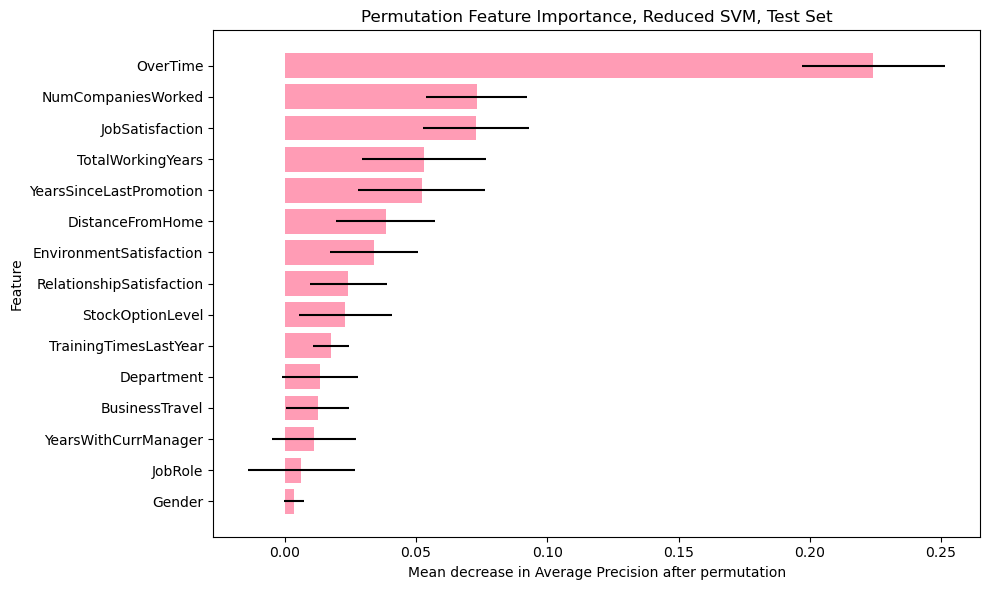

In [47]:
# Cell 15: Plot top 15 PFI features

import matplotlib.pyplot as plt

top_n = 15
plot_df = pfi_df.head(top_n).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"],
    color="#FF9CB5"
)
plt.xlabel("Mean decrease in Average Precision after permutation")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance, Reduced SVM, Test Set")
plt.tight_layout()
plt.show()

In [41]:
# Cell 16: Optional PFI sanity check using ROC-AUC

pfi_result_roc = permutation_importance(
    estimator=svm_pipe,
    X=X_test,
    y=y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

pfi_df_roc = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean_roc": pfi_result_roc.importances_mean,
    "importance_std_roc": pfi_result_roc.importances_std
}).sort_values("importance_mean_roc", ascending=False).reset_index(drop=True)

print("=== Optional PFI ranking (scoring = roc_auc) ===")
pfi_df_roc.head(15)

=== Optional PFI ranking (scoring = roc_auc) ===


,feature,importance_mean_roc,importance_std_roc
0,OverTime,0.098269,0.016356
1,NumCompaniesWorked,0.035037,0.013034
2,YearsSinceLastPromotion,0.026135,0.008533
3,StockOptionLevel,0.025782,0.008927
4,JobSatisfaction,0.024817,0.006176
5,EnvironmentSatisfaction,0.013864,0.008164
6,DistanceFromHome,0.012202,0.012502
7,TotalWorkingYears,0.010823,0.017610
8,PercentSalaryHike,0.010539,0.007019
9,TrainingTimesLastYear,0.009389,0.004601


In [43]:
# Cell 17: Compare AP-based and ROC-AUC-based PFI rankings

pfi_compare = (
    pfi_df[["feature", "rank", "importance_mean", "importance_std"]]
    .rename(columns={
        "rank": "rank_ap",
        "importance_mean": "importance_mean_ap",
        "importance_std": "importance_std_ap"
    })
    .merge(
        pfi_df_roc.reset_index().rename(columns={"index": "rank_roc"})[
            ["feature", "rank_roc", "importance_mean_roc", "importance_std_roc"]
        ],
        on="feature",
        how="left"
    )
)

pfi_compare["rank_roc"] = pfi_compare["rank_roc"] + 1
pfi_compare.sort_values("rank_ap").head(15)

,feature,rank_ap,importance_mean_ap,importance_std_ap,rank_roc,importance_mean_roc,importance_std_roc
0,OverTime,1,0.224201,0.027336,1,0.098269,0.016356
1,NumCompaniesWorked,2,0.073062,0.019148,2,0.035037,0.013034
2,JobSatisfaction,3,0.072854,0.020185,5,0.024817,0.006176
3,TotalWorkingYears,4,0.053081,0.023581,8,0.010823,0.017610
4,YearsSinceLastPromotion,5,0.052222,0.024134,3,0.026135,0.008533
5,DistanceFromHome,6,0.038486,0.018912,7,0.012202,0.012502
6,EnvironmentSatisfaction,7,0.034026,0.016594,6,0.013864,0.008164
7,RelationshipSatisfaction,8,0.024194,0.014625,11,0.008399,0.010505
8,StockOptionLevel,9,0.023076,0.017731,4,0.025782,0.008927
9,TrainingTimesLastYear,10,0.017704,0.006761,10,0.009389,0.004601


# ALE

In [51]:
# Cell 19: imports for ALE

from PyALE import ale
import matplotlib.pyplot as plt

Justification for ALE feature choice: 
* OverTime: rank 1 in both AP and ROC, huge gap to other features meaning it's a clearly dominant driver, very interpretable
* NumCompaniesWorked: rank 2 in both AP and ROC, strong and stable across metrics, numeric feature which works well with ALE curve
* TotalWorkingYears: rank 4 in AP and slight drop in ROC but still strong. complements numcompaniesworked (career trajectory)
* JobSatisfaction: has high AP (rank 3) but ROC rank is 5 meaning it's less stable. It's also slightly more subjective / harder to interpret cleanly
* YearsSinceLastPromotion: AP rank 5, ROC rank 3. good candidate but overlaps conceptually with TotalWorkingYears and slightly less intuitive than total experience
* StockOptionLevel: good ROC importance but lower AP ranking and less intuitive for ALE storytelling

In [57]:
# Cell 20: choose features for ALE

ale_features = [
    "OverTime",
    "NumCompaniesWorked",
    "TotalWorkingYears"
]

print("Selected ALE features:", ale_features)

Selected ALE features: ['OverTime', 'NumCompaniesWorked', 'TotalWorkingYears']


In [59]:
# Cell 21: prediction function for ALE

def predict_attrition_proba(X_input):
    return svm_pipe.predict_proba(X_input)[:, 1]


Running ALE for: OverTime


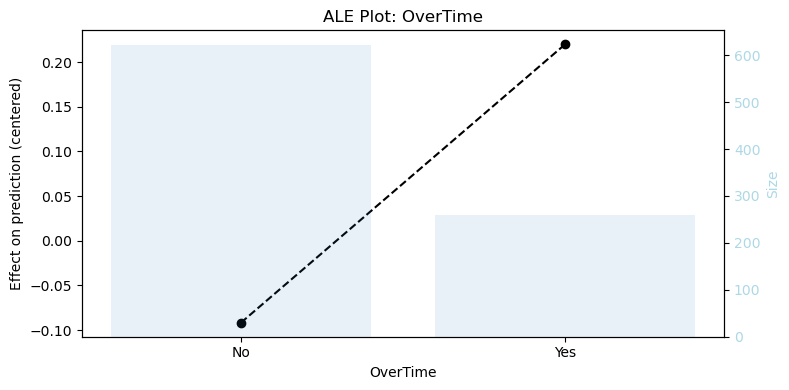


Running ALE for: NumCompaniesWorked


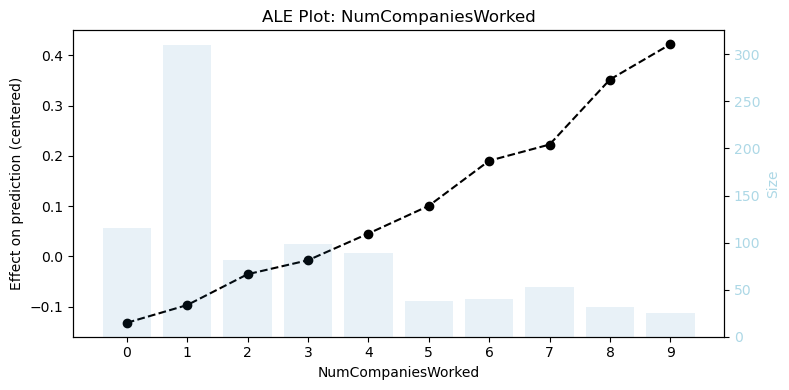


Running ALE for: TotalWorkingYears


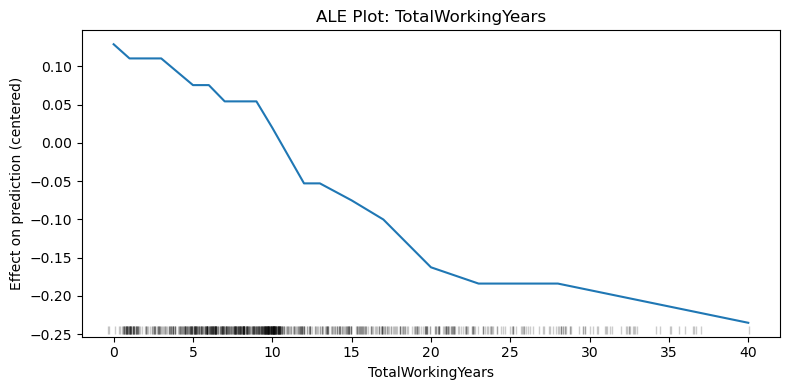

In [71]:
# Cell 22 alternative: loop through ALE features

for feat in ale_features:
    print(f"\nRunning ALE for: {feat}")
    
    feature_type = "discrete" if X_train[feat].dtype == "object" or X_train[feat].nunique() <= 10 else "continuous"
    
    ale(
        X=X_train,
        model=svm_pipe,
        feature=[feat],
        feature_type=feature_type,
        grid_size=20,
        include_CI=False,
        plot=True,
        contour=False, 
    )
    
    plt.title(f"ALE Plot: {feat}")
    plt.tight_layout()
    plt.show()

Insights (tbc later) 
* TotalWorkingYears: flattening after ~25 years

# SHAP

as blackbox model is SVM, SHAP will use KernelExplainer which is slow. so must sample data and be careful with runtime. plan is to: 
1. create background dataset from X_train & sample of test data for explanation
2. run SHAP values
3. produce summary plot for global importance, and dependence plot that ties nicely with ALE

In [78]:
# Cell 26: imports for SHAP

import shap
import matplotlib.pyplot as plt

In [131]:
# Cell 27: sample background and test rows for Kernel SHAP

BACKGROUND_SIZE = 250
EXPLAIN_SIZE = 180

X_background = X_train.sample(n=BACKGROUND_SIZE, random_state=42).copy()
X_explain = X_test.sample(n=EXPLAIN_SIZE, random_state=42).copy()

print("X_background shape:", X_background.shape)
print("X_explain shape:", X_explain.shape)

X_background shape: (250, 22)
X_explain shape: (180, 22)


In [132]:
# Cell 28: prediction function for SHAP

def predict_attrition_proba_shap(X_input):
    X_input_df = pd.DataFrame(X_input, columns=X_model.columns)
    return svm_pipe.predict_proba(X_input_df)[:, 1]

In [133]:
# Cell 29: initialize Kernel SHAP explainer

explainer = shap.KernelExplainer(
    model=predict_attrition_proba_shap,
    data=X_background
)

shap:WARNING: Using 250 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


In [134]:
# Cell 30: compute SHAP values for sampled test rows

shap_values = explainer.shap_values(
    X_explain,
    nsamples=150
)

print("SHAP values shape:", np.array(shap_values).shape)

  0%|          | 0/180 [00:00<?, ?it/s]

SHAP values shape: (180, 22)


In [135]:
# try this if runtime too slow 
# nsamples=50

# BACKGROUND_SIZE = 50
# EXPLAIN_SIZE = 30
# nsamples = 50

In [136]:
# Cell 31: standardize SHAP output shape

shap_values_array = np.array(shap_values)

# For binary classification with KernelExplainer, sometimes output is already 2D
if shap_values_array.ndim == 2:
    shap_values_final = shap_values_array

# In some versions it may return shape like (n_samples, n_features, 2)
elif shap_values_array.ndim == 3:
    shap_values_final = shap_values_array[:, :, 1]

# In other versions it may return list-like class outputs
else:
    shap_values_final = shap_values[1]

print("Final SHAP matrix shape:", shap_values_final.shape)

Final SHAP matrix shape: (180, 22)


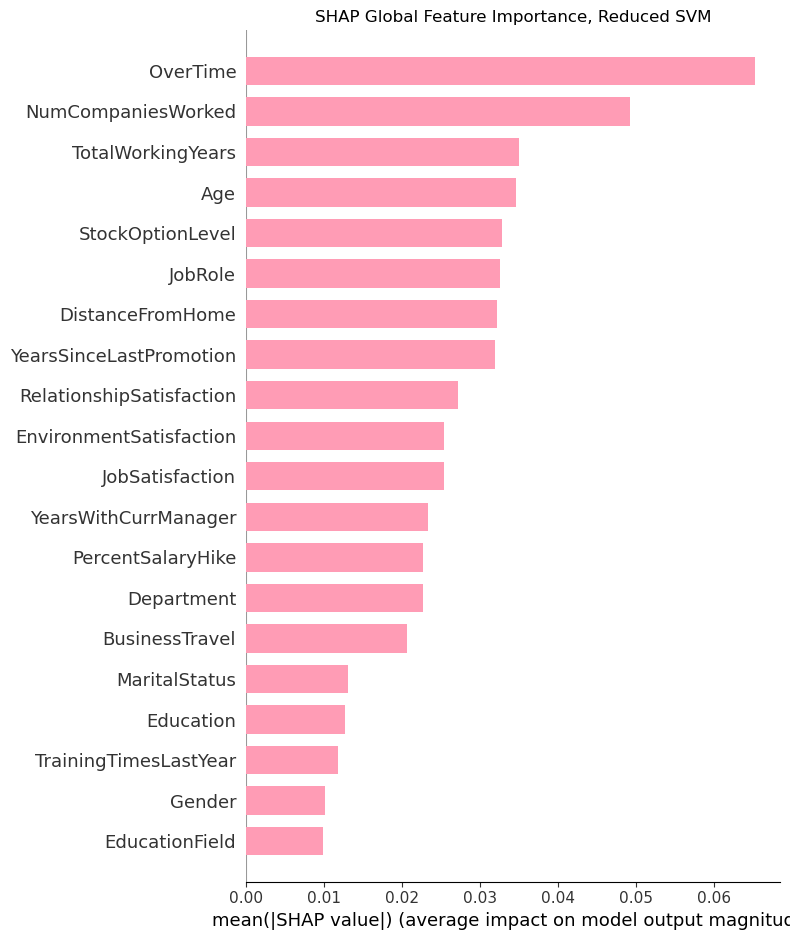

In [137]:
# Cell 32: SHAP summary plot (bar)

shap.summary_plot(
    shap_values_final,
    X_explain,
    plot_type="bar",
    show=False,
    color="#FF9CB5"
)

plt.title("SHAP Global Feature Importance, Reduced SVM")
plt.tight_layout()
plt.show()

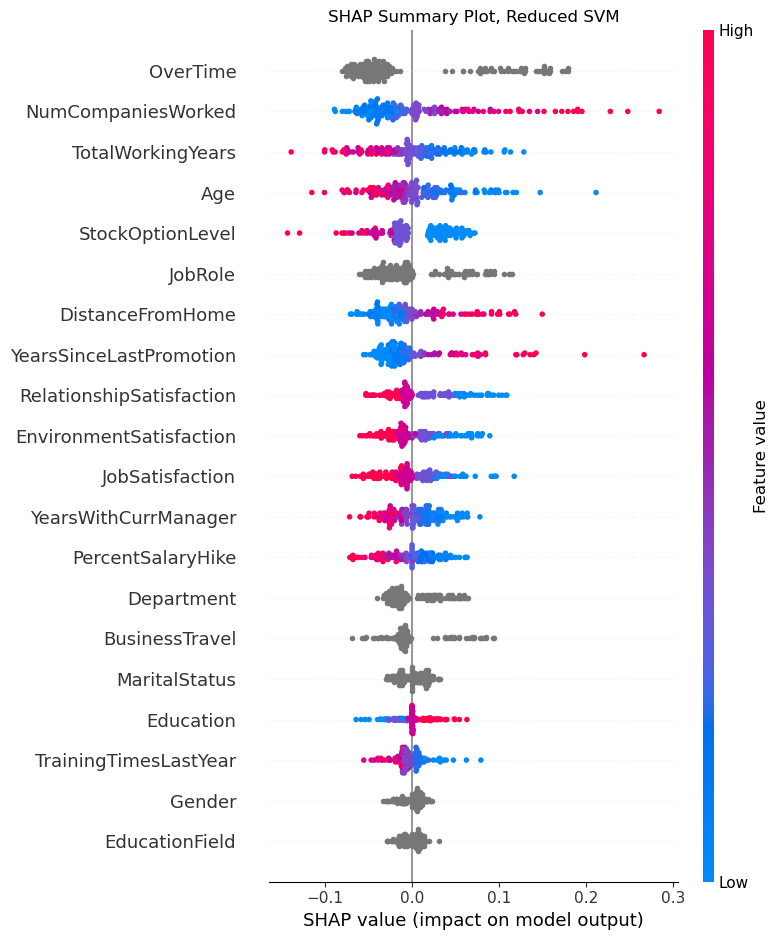

In [138]:
# Cell 33: SHAP summary beeswarm plot

shap.summary_plot(
    shap_values_final,
    X_explain,
    show=False
)

plt.title("SHAP Summary Plot, Reduced SVM")
plt.tight_layout()
plt.show()

In [139]:
# Cell 34: mean absolute SHAP importance table

mean_abs_shap = np.abs(shap_values_final).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": X_explain.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

shap_importance_df["rank"] = np.arange(1, len(shap_importance_df) + 1)

print("=== Global SHAP Importance Ranking ===")
shap_importance_df.head(15)

=== Global SHAP Importance Ranking ===


,feature,mean_abs_shap,rank
0,OverTime,0.065223,1
1,NumCompaniesWorked,0.049260,2
2,TotalWorkingYears,0.034980,3
3,Age,0.034596,4
4,StockOptionLevel,0.032868,5
5,JobRole,0.032540,6
6,DistanceFromHome,0.032207,7
7,YearsSinceLastPromotion,0.031973,8
8,RelationshipSatisfaction,0.027180,9
9,EnvironmentSatisfaction,0.025418,10


Top SHAP features: ['OverTime', 'NumCompaniesWorked', 'TotalWorkingYears']


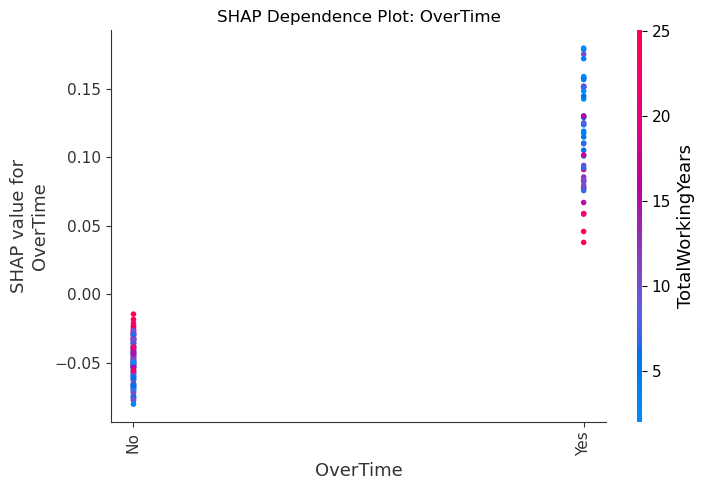

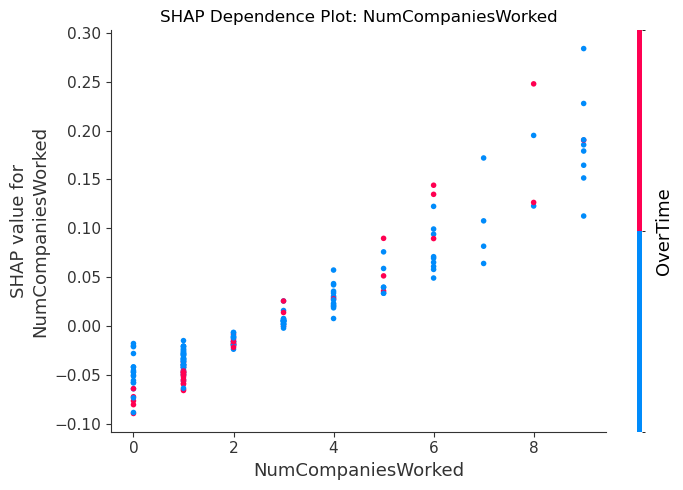

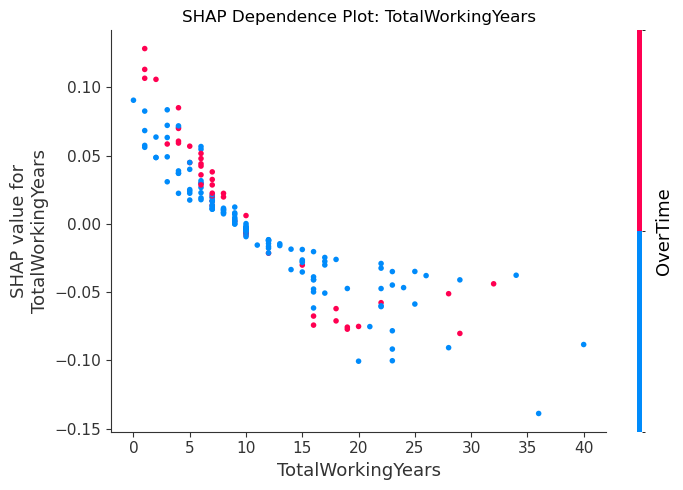

In [140]:
# Cell 35: SHAP dependence plots for selected features

top_shap_features = shap_importance_df["feature"].head(3).tolist()
print("Top SHAP features:", top_shap_features)

for feat in top_shap_features:
    shap.dependence_plot(
        ind=feat,
        shap_values=shap_values_final,
        features=X_explain,
        show=False
    )
    plt.title(f"SHAP Dependence Plot: {feat}")
    plt.tight_layout()
    plt.show()

# Feature Interaction Analysis using SHAP Dependence Plots

Initially, we planned to compute SHAP interaction values directly. However, after implementation, we found that SHAP interaction values are not properly supported for SVM models using KernelExplainer (they are mainly designed for tree-based models with TreeExplainer). To ensure methodological correctness and avoid unreliable results, we instead used SHAP dependence plots with specified interaction features. These plots allow us to visually analyse how one feature’s effect depends on another, which still achieves the goal of identifying interaction effects while remaining consistent with our chosen model.

for each feature: 
* x axis: feature value
* y axis: SHAP value
* colour: interacting feature

Top features for interaction exploration: ['OverTime', 'NumCompaniesWorked', 'TotalWorkingYears', 'Age', 'StockOptionLevel']


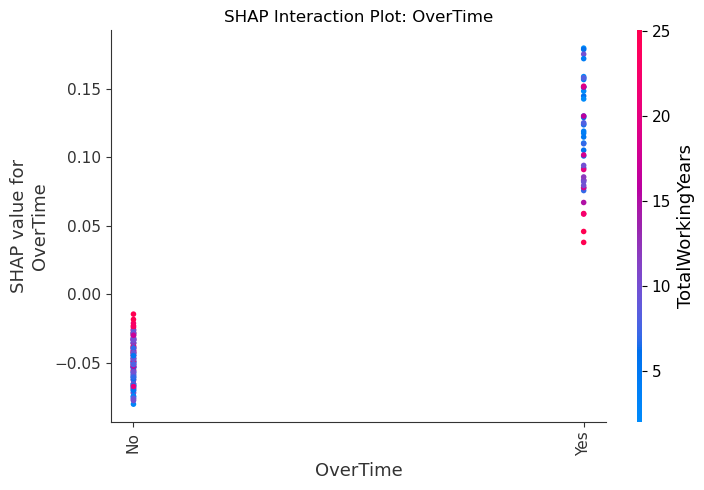

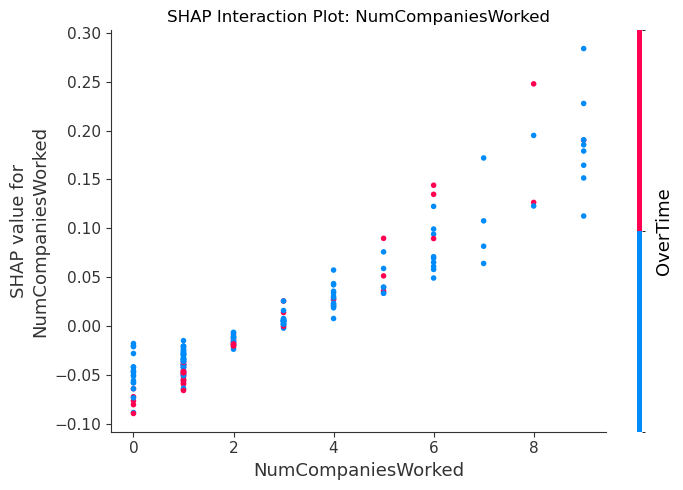

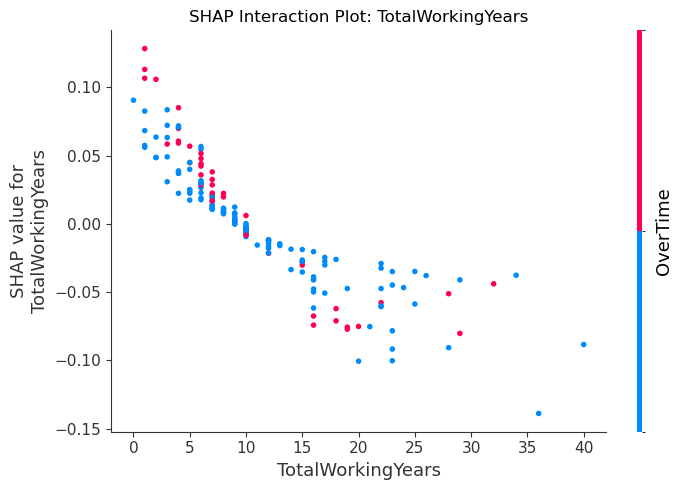

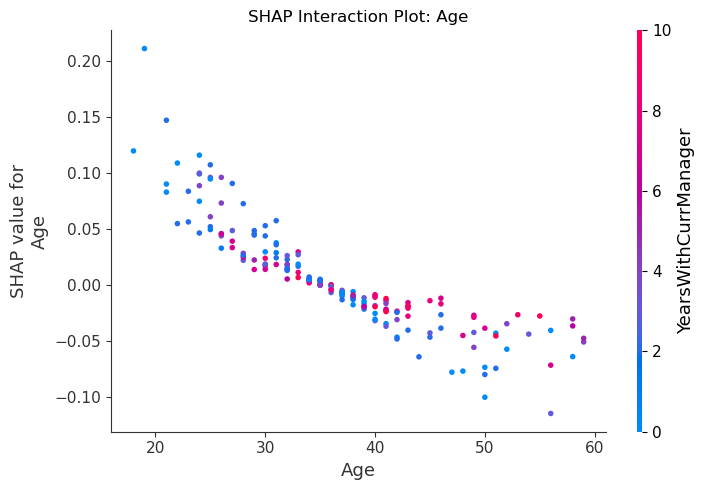

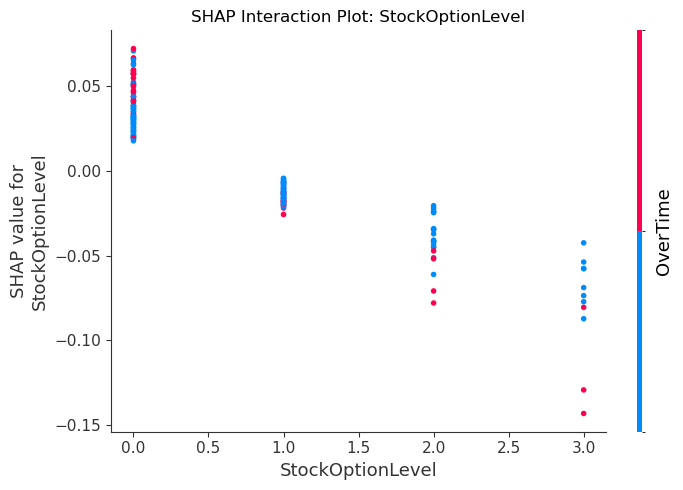

In [156]:
# SHAP interaction-style plots using dependence plots

top_features = shap_importance_df["feature"].head(5).tolist()

print("Top features for interaction exploration:", top_features)

for feat in top_features:
    shap.dependence_plot(
        ind=feat,
        shap_values=shap_values_final,
        features=X_explain,
        interaction_index="auto",  # SHAP picks strongest interacting feature
        show=False
    )
    plt.title(f"SHAP Interaction Plot: {feat}")
    plt.tight_layout()
    plt.show()

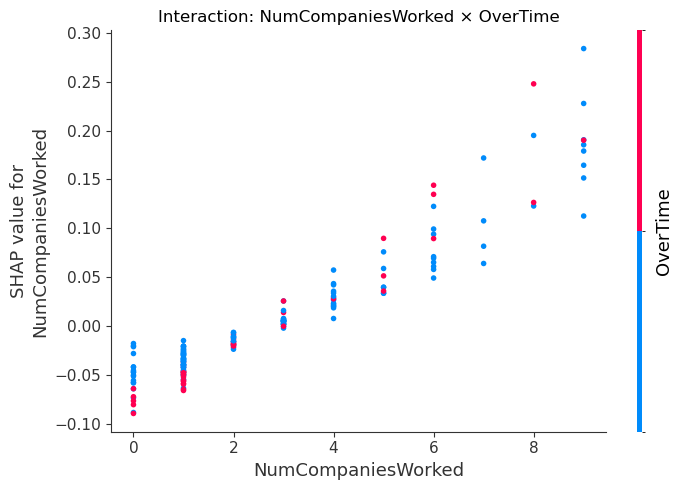

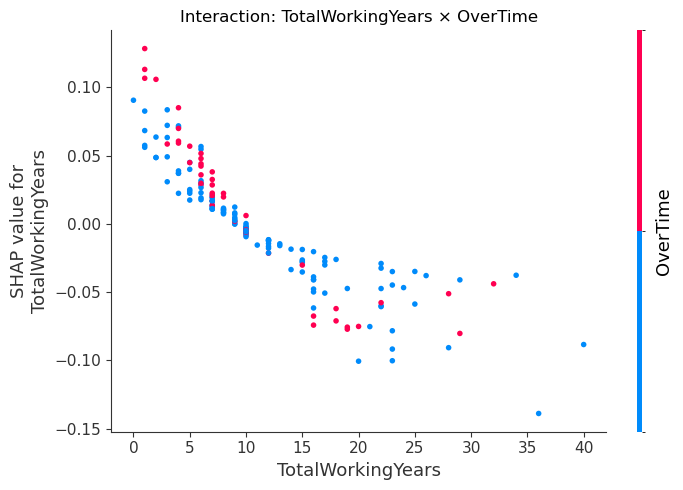

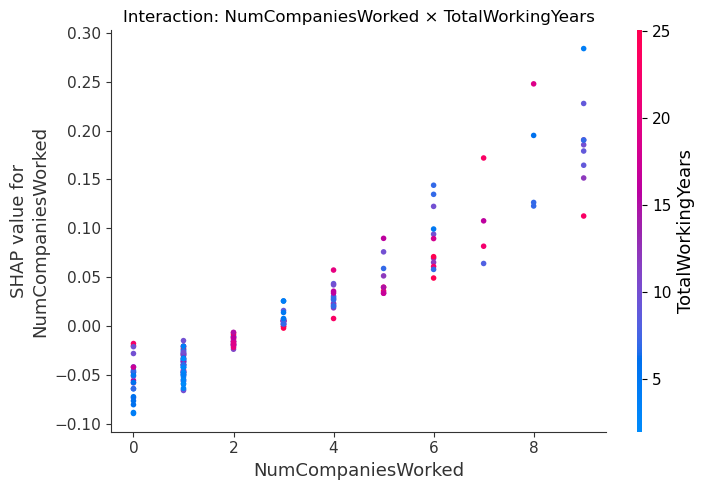

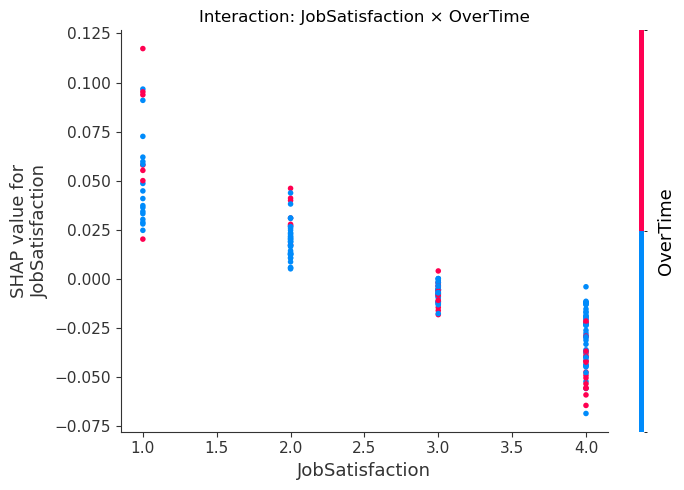

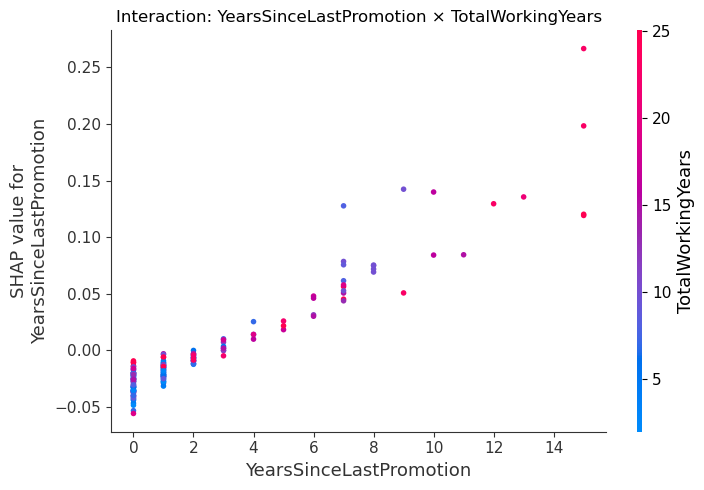

In [165]:
# SHAP interaction-focused plots

interaction_pairs = [
    ("NumCompaniesWorked", "OverTime"),
    ("TotalWorkingYears", "OverTime"),
    ("NumCompaniesWorked", "TotalWorkingYears"), 
    ("JobSatisfaction", "OverTime"), 
    ("YearsSinceLastPromotion", "TotalWorkingYears")
]

for main_feat, interact_feat in interaction_pairs:
    shap.dependence_plot(
        ind=main_feat,
        shap_values=shap_values_final,
        features=X_explain,
        interaction_index=interact_feat,
        show=False
    )
    
    plt.title(f"Interaction: {main_feat} × {interact_feat}")
    plt.tight_layout()
    plt.show()